In [29]:
from langgraph.graph import StateGraph , START , END
from typing import TypedDict , Annotated
import os
from dotenv import load_dotenv
from pydantic import BaseModel ,Field
from langchain_google_genai import ChatGoogleGenerativeAI
import operator

In [30]:
load_dotenv()

True

In [31]:
GEMINI_API_KEY = os.getenv("GEMINI_API_KEY")
model = ChatGoogleGenerativeAI(model="gemini-1.5-flash",google_api_key=GEMINI_API_KEY)

In [ ]:
class EvaluationSchema(BaseModel):
    feedback:str = Field(description="Detailed feedback for the essay")
    score:int =Field(description="Score out of 10 ",ge=0,le=10)

structured_model = model.with_structured_output(EvaluationSchema)

In [46]:
essay = """
Now a days many people use internet. It is very good because it can talk to people and also do many thing like see movies, send picture. Some people think that internet make people to close, which is true because when I talk my cousin who live in Dubai, I can see him and this is good. But some persons think internet is bad because people don’t go outside and just sit on phone all day, that is not good for health and mind. I also think that some peoples are not talking to family anymore only chatting with friends on internet. This is not nice. In my opinion internet is good if you use it good but not good if you use too much. Many children now don’t play outside and only look at screen, so internet is make them lazy and fat. So I think both are right but internet is more good if use careful. Thank you.
"""

In [34]:
prompt = f'evaluate the language quality of the following essay and give a score out of 10 {essay}'
structured_model.invoke(prompt)

EvaluationSchema(feedback='The essay is well-structured and clearly written, demonstrating a good understanding of the topic. The language is concise and precise, with effective use of vocabulary. There is a strong argumentative flow, and the conclusion effectively summarizes the main points. Minor improvements could be made in terms of sentence variation and the use of more specific examples to support the claims. ', score=8)

In [43]:
def evaluation_language(state:EssayState):
    prompt = f'evaluate the language quality of the following essay and give a score out of 10 {essay}'
    output = structured_model.invoke(prompt)

    return {'language_feedback':output.feedback,'score_list':[output.score]}

def evaluation_analysis(state:EssayState):
    prompt = f'evaluate the analysis of the following essay and give a score out of 10 {essay}'
    output = structured_model.invoke(prompt)

    return {'analysis_feedback':output.feedback,'score_list':[output.score]}

def evaluation_clarity(state:EssayState):
    prompt = f'evaluate the clarity of the following essay and give a score out of 10 {essay}'
    output = structured_model.invoke(prompt)

    return {'clarity_feedback':output.feedback,'score_list':[output.score]}

def final_evaluation(state:EssayState):
    prompt = f'evaluate the overall quality of the following essay  based on the feedback {state["language_feedback"]}, {state["analysis_feedback"]}, {state["clarity_feedback"]}'
    output = structured_model.invoke(prompt)

    avg_score = sum(state['score_list'])/len(state['score_list'])
    return {'final_feedback':output.feedback,'avg_score':avg_score}

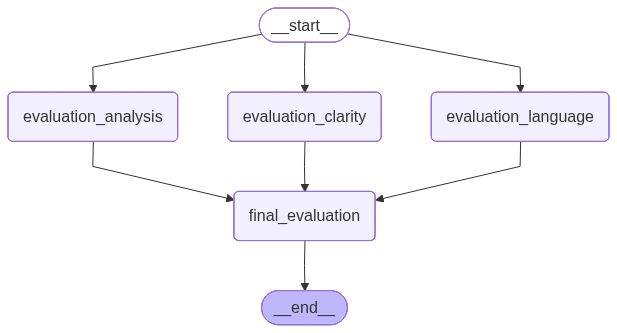

In [44]:
class EssayState(TypedDict):
    essay:str
    language_feedback:str
    analysis_feedback:str
    clarity_feedback:str
    final_feedback:str
    score_list:Annotated[list[int],operator.add]
    avg_score:float

graph = StateGraph(EssayState)

graph.add_node('evaluation_language',evaluation_language)
graph.add_node('evaluation_analysis',evaluation_analysis)
graph.add_node('evaluation_clarity',evaluation_clarity)
graph.add_node('final_evaluation',final_evaluation)

graph.add_edge(START,'evaluation_language')
graph.add_edge(START,'evaluation_analysis')
graph.add_edge(START,'evaluation_clarity')

graph.add_edge('evaluation_language','final_evaluation')
graph.add_edge('evaluation_analysis','final_evaluation')
graph.add_edge('evaluation_clarity','final_evaluation')

graph.add_edge('final_evaluation',END)

workflow = graph.compile()
workflow

In [47]:
initial_state = {
    'essay':essay
}

workflow.invoke(initial_state)

{'essay': '\nNow a days many people use internet. It is very good because it can talk to people and also do many thing like see movies, send picture. Some people think that internet make people to close, which is true because when I talk my cousin who live in Dubai, I can see him and this is good. But some persons think internet is bad because people don’t go outside and just sit on phone all day, that is not good for health and mind. I also think that some peoples are not talking to family anymore only chatting with friends on internet. This is not nice. In my opinion internet is good if you use it good but not good if you use too much. Many children now don’t play outside and only look at screen, so internet is make them lazy and fat. So I think both are right but internet is more good if use careful. Thank you.\n',
 'language_feedback': "The essay demonstrates a basic understanding of the topic and presents a balanced perspective on the internet's impact. However, the writing is qui